In [ ]:
pip install pymysql sqlalchemy pandas matplotlib seaborn

In [3]:
import pandas as pd
from sqlalchemy import create_engine

In [4]:
# 1) 접속 정보 설정
USER = "root"          # MySQL 계정
PASSWORD = "123456"
HOST = "localhost"     # 도커 컨테이너를 호스트로 포워딩했으면 보통 localhost
PORT = "3400"          # docker run -p 3306:3306 했다고 가정
DB = "docker_mysql"   # 사용 중인 DB 이름

In [8]:
# 2) SQLAlchemy 엔진 생성
engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB}?charset=utf8mb4")

# 3) 일별 출석 유저 수 쿼리 (이미 MySQL에서 쓰던 쿼리 넣으면 됨)
query = """
select 
    reason,
    count(block_user_id) as block_count
from accounts_blockrecord
group by reason
;
"""

In [9]:
# 4) pandas DataFrame으로 읽어오기
df = pd.read_sql(query, con=engine)
df.head()

,reason,block_count
0,그냥...,6
1,친구 사이가 어색해짐,5805
2,나랑 관련 없는 질문을 자꾸 보냄,1083
3,기타,7
4,모르는 사람임,9640


In [ ]:
%pip install koreanize-matplotlib

import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

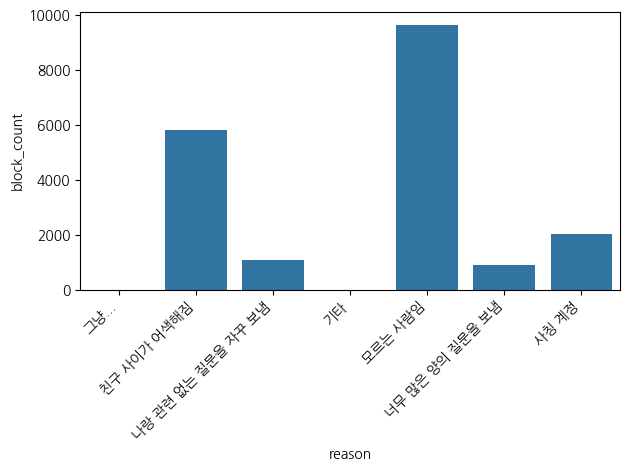

In [17]:
# 차단 이유별 차단 수
sns.barplot(
    data=df,
    x='reason',
    y='block_count'
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [21]:
failpayment_query = """
SELECT
    productId,
    COUNT(created_at) as count
FROM accounts_failpaymenthistory
GROUP BY productId
"""

failpayment_df = pd.read_sql(failpayment_query, con=engine)
failpayment_df.head()


,productId,count
0,heart.200,3
1,heart.777,49
2,heart.1000,4
3,None,107


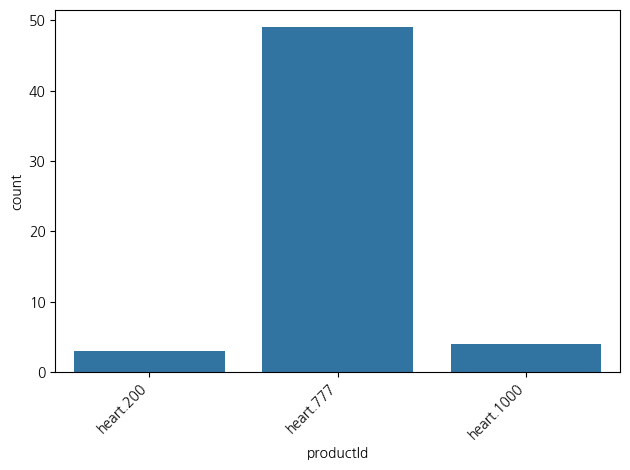

In [22]:
# 상품 별 구매 실패 수
sns.barplot(
    data=failpayment_df,
    x='productId',
    y='count'
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()